<a href="https://colab.research.google.com/github/danielarodriguez4/Stress-Sleep-Patterns-Analysis/blob/main/sp_3_Daniela_Rodriguez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

* María Daniela Rodríguez Chacón
* CC 1126911848
* mdaniela.rodriguez@udea.edu.co




## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

#### Importación de librerías

In [ ]:
from sklearn.datasets import load_wine
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#### 1, 2. Carga del conjunto de datos y conversión a DataFrame de *pandas*

In [ ]:
df = pd.DataFrame(load_wine().data, columns=load_wine().feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


#### 3. Para aplicar los métodos de escalamiento, se escogieron las siguientes variables numéricas:

*   `alcohol`
*   `total_phenols`
*  `nonflavanoid_phenols`



#### 4. Métodos de escalamiento

##### Escalamiento con `StandardScaler`

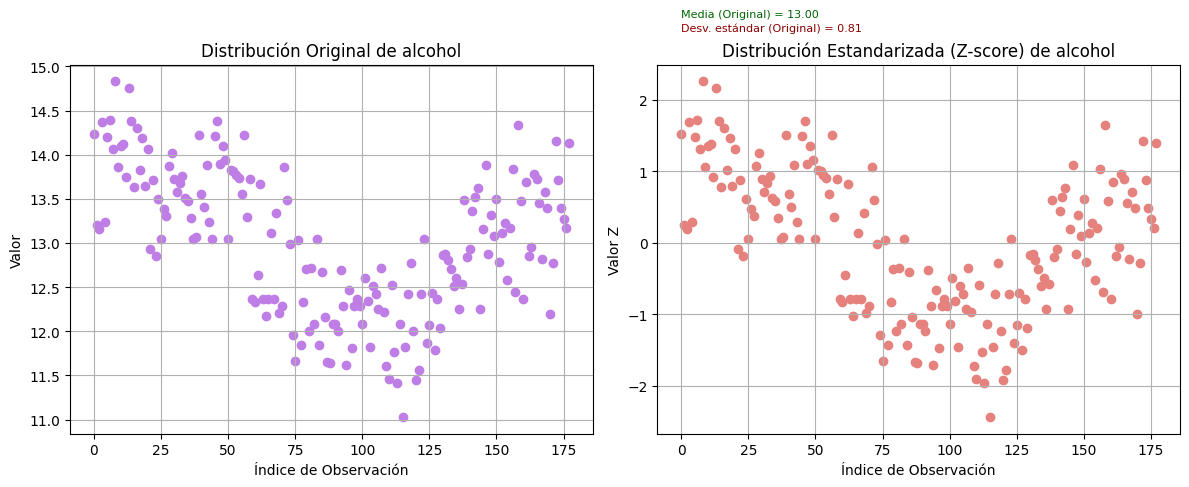

In [ ]:
#Variables seleccionadas para análsis
selected_features = ['alcohol', 'total_phenols', 'nonflavanoid_phenols']

#Se crea un dataset con las variables escogidas
datos_para_escalar = df[selected_features].values

#Se aplica el escalamiento estándar
scaler = StandardScaler()
datos_estandarizados_all = scaler.fit_transform(datos_para_escalar)

#Para visualización se selecciona la variable 'alcohol'
variable_to_plot_index = 0
valores_originales = datos_para_escalar[:, variable_to_plot_index]
valores_zscore = datos_estandarizados_all[:, variable_to_plot_index]

indices = np.arange(len(valores_originales))

media = np.mean(valores_originales)
std = np.std(valores_originales)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#Gráfico 1: datos originales con outlier (for 'alcohol')
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title(f'Distribución original de {selected_features[variable_to_plot_index]}')
axs[0].set_xlabel('Índice de observación')
axs[0].set_ylabel('Valor')
axs[0].grid(True)

# Gráfico 2: datos estandarizados (Z-score) con outlier (for 'alcohol')
axs[1].scatter(indices, valores_zscore, color='#E6827E')
axs[1].set_title(f'Distribución Estandarizada (Z-score) de {selected_features[variable_to_plot_index]}')
axs[1].set_xlabel('Índice de observación')
axs[1].set_ylabel('Valor Z')
axs[1].grid(True)

# Anotaciones de media y desviación estándar
axs[1].text(indices[0], np.max(valores_zscore) + 0.9, f'Media (Original) = {media:.2f}', fontsize=8, color='darkgreen')
axs[1].text(indices[0], np.max(valores_zscore) + 0.7, f'Desv. estándar (Original) = {std:.2f}', fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

#### Distribución con `MinMaxScaler`

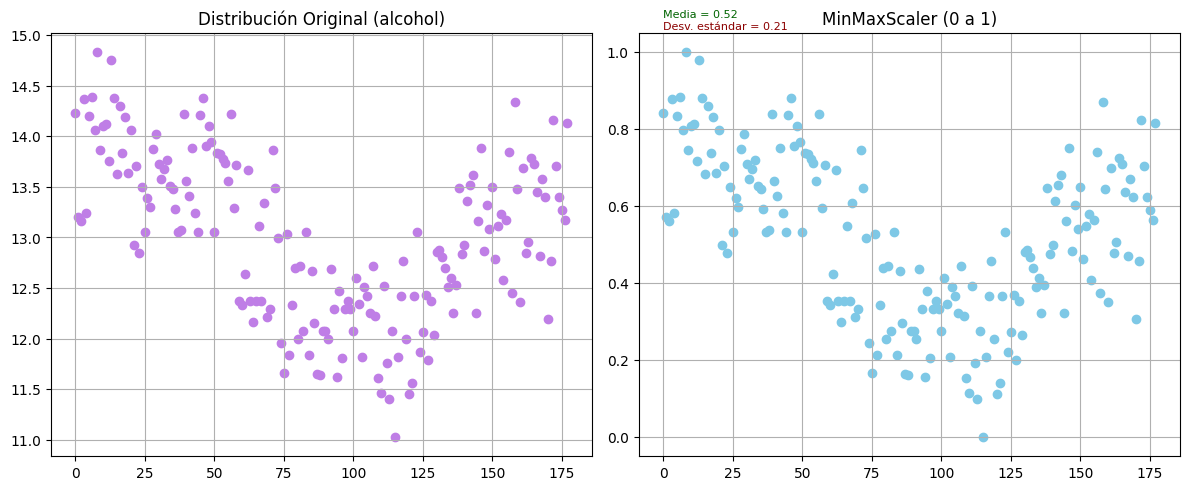

In [ ]:
scaler = MinMaxScaler()
datos_minmax = scaler.fit_transform(datos_para_escalar)

valores_escalados = datos_minmax[:, variable_to_plot_index]

#Métricas de los datos escalados
media_escalada = np.mean(valores_escalados)
std_escalada = np.std(valores_escalados)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#Gráfico 1: datos originales con outlier (for 'alcohol')
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title('Distribución Original (alcohol)')
axs[0].grid(True)

# Gráfico 2: datos estandarizados (MinMaxScaler) con outlier (for 'alcohol')
axs[1].scatter(indices, valores_escalados, color='#7EC8E6')
axs[1].set_title('MinMaxScaler (0 a 1)')
axs[1].grid(True)

y_max = np.max(valores_escalados)

axs[1].text(indices[0], y_max + 0.09,
            f'Media = {media_escalada:.2f}',
            fontsize=8, color='darkgreen')

axs[1].text(indices[0], y_max + 0.06,
            f'Desv. estándar = {std_escalada:.2f}',
            fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

#### Distribución con `RobustScaler`

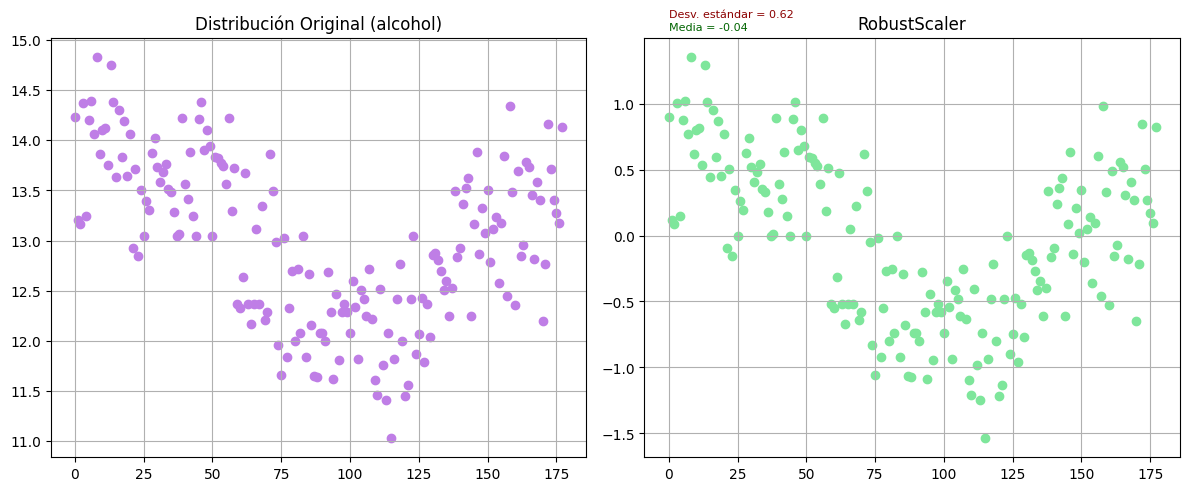

In [ ]:
scaler = RobustScaler()
datos_robust = scaler.fit_transform(datos_para_escalar)

valores_escalados = datos_robust[:, variable_to_plot_index]

#Métricas de los datos escalados
media_escalada = np.mean(valores_escalados)
std_escalada = np.std(valores_escalados)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#Gráfico 1: datos originales con outlier (for 'alcohol')
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title('Distribución Original (alcohol)')
axs[0].grid(True)

#Gráfico 2: datos estandarizados (RobustScaler) con outlier (for 'alcohol')
axs[1].scatter(indices, valores_escalados, color='#7EE69B')
axs[1].set_title('RobustScaler')
axs[1].grid(True)

y_max = np.max(valores_escalados)

axs[1].text(indices[0], y_max + 0.2,
            f'Media = {media_escalada:.2f}',
            fontsize=8, color='darkgreen')

axs[1].text(indices[0], y_max + 0.3,
            f'Desv. estándar = {std_escalada:.2f}',
            fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

#### Distribución con `Z-score` manual

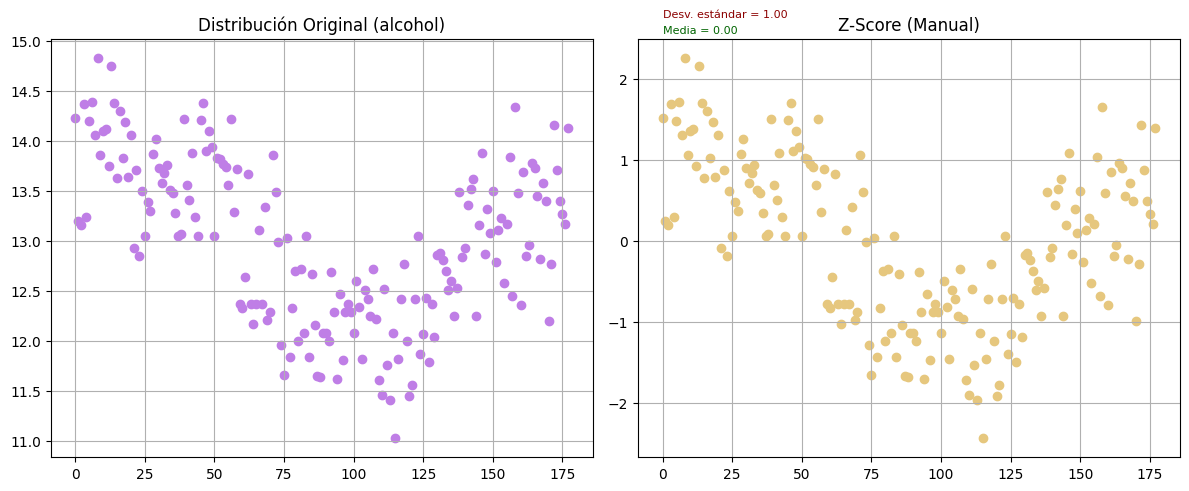

In [ ]:
media = np.mean(datos_para_escalar, axis=0)
std = np.std(datos_para_escalar, axis=0)

datos_zscore = (datos_para_escalar - media) / std

valores_escalados = datos_zscore[:, variable_to_plot_index]

#Métricas de los datos escalados
media_escalada = np.mean(valores_escalados)
std_escalada = np.std(valores_escalados)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

#Gráfico 1: datos originales con outlier (for 'alcohol')
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title('Distribución Original (alcohol)')
axs[0].grid(True)

#Gráfico 2: datos estandarizados (Z-score manual) con outlier (for 'alcohol')

axs[1].scatter(indices, valores_escalados, color='#E6C77E')
axs[1].set_title('Z-Score (Manual)')
axs[1].grid(True)

y_max = np.max(valores_escalados)

axs[1].text(indices[0], y_max + 0.3,
            f'Media = {media_escalada:.2f}',
            fontsize=8, color='darkgreen')

axs[1].text(indices[0], y_max + 0.5,
            f'Desv. estándar = {std_escalada:.2f}',
            fontsize=8, color='darkred')

plt.tight_layout()
plt.show()

#### 6. Análisis

Los métodos de escalamiento cambian la escala de los datos, pero no su forma. `StandardScaler` y `Z-Score` dejan los datos centrados en 0 y son útiles cuando todo está más o menos distribuido normalmente. `MinMaxScaler` los lleva a un rango entre 0 y 1, pero se puede ver afectado por valores extremos. RobustScaler usa la mediana, por lo que es más estable cuando hay outliers. En este caso, **`RobustScaler`** sería el más recomendable porque no se ve tan afectado por esos valores atípicos.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

Librerías

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np
import matplotlib.pyplot as plt

#### 1. Carga y preparación de datos

In [ ]:
diabetes = load_diabetes()

#### 2. Conversión a DataFrame e identificación de variables

In [ ]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


#### 3. Selección de variables

In [ ]:
selected_features = ['bmi', 'bp', 's2']
datos_para_escalar = df[selected_features].values

#### 4. Métodos de escalamiento

`StandardScaler`

In [ ]:
scaler_z = StandardScaler()
datos_zscore = scaler_z.fit_transform(datos_para_escalar)

`RobustScaler`

In [ ]:
scaler_robust = RobustScaler()
datos_robust = scaler_robust.fit_transform(datos_para_escalar)

#### 5. Gráficas comparativas de la variable bp

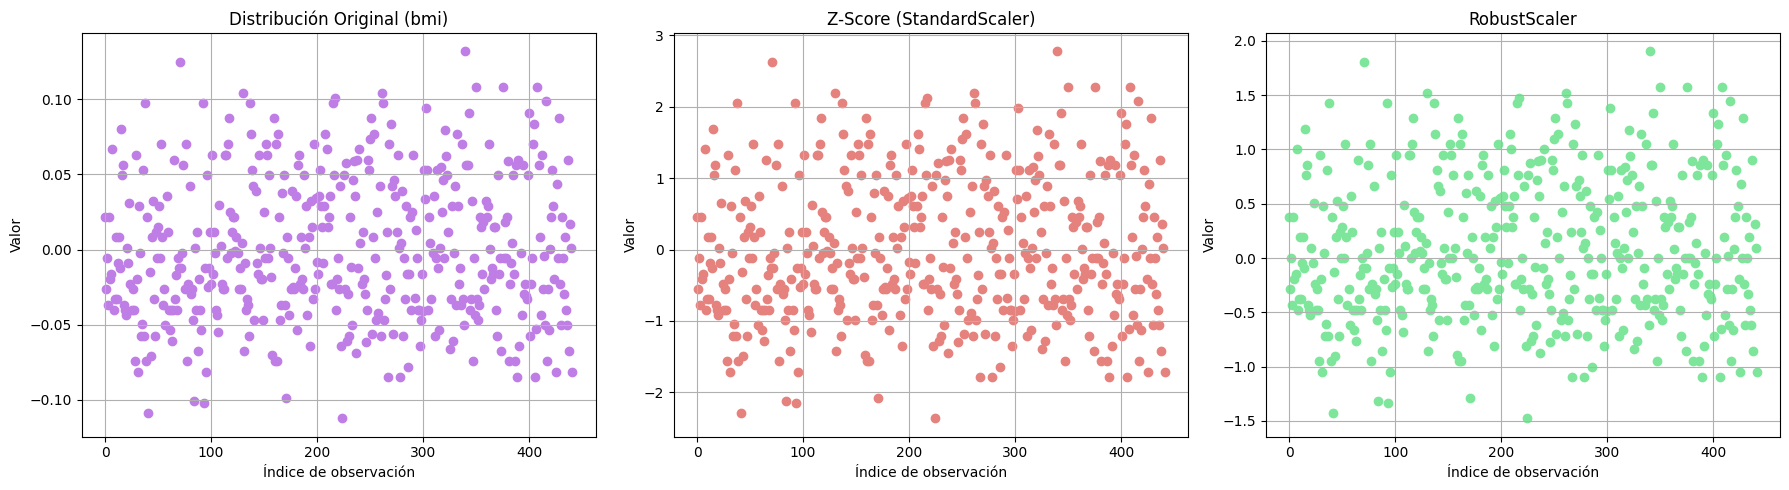

In [ ]:
variable_to_plot_index = 1  #bp

valores_originales = datos_para_escalar[:, variable_to_plot_index]
valores_z = datos_zscore[:, variable_to_plot_index]
valores_robust = datos_robust[:, variable_to_plot_index]

indices = np.arange(len(valores_originales))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

#Gráfica 1: Distribución original
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title('Distribución Original (bmi)')
axs[0].set_xlabel('Índice de observación')
axs[0].set_ylabel('Valor')
axs[0].grid(True)

#Gráfica 2: Z-Score
axs[1].scatter(indices, valores_z, color='#E6827E')
axs[1].set_title('Z-Score (StandardScaler)')
axs[1].set_xlabel('Índice de observación')
axs[1].set_ylabel('Valor')
axs[1].grid(True)

#Gráfica 3: RobustScaler
axs[2].scatter(indices, valores_robust, color='#7EE69B')
axs[2].set_title('RobustScaler')
axs[2].set_xlabel('Índice de observación')
axs[2].set_ylabel('Valor')
axs[2].grid(True)

plt.tight_layout()
plt.show()

#### 6. Análisis

El `Z-Score` transforma los datos para que tengan media 0 y desviación estándar 1, pero es sensible a valores atípicos, lo que puede hacer que estos se vean más extremos. Por otro lado, `RobustScaler` usa la mediana y el rango intercuartílico, por lo que reduce el impacto de esos valores extremos. En las gráficas se nota que con `Z-Score` los datos están más dispersos, mientras que con `RobustScaler` se ven más equilibrados. Esto hace que la distribución sea más estable. Por eso, cuando hay posibles outliers, es más recomendable usar `RobustScaler`.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

#### Librerías

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import Normalizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### 1. Carga de datos

In [ ]:
housing = fetch_california_housing()

#### 2. Conversión a DataFrame

In [ ]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


#### 3. Selección de variables

In [ ]:
selected_features = ['HouseAge','AveRooms','Population']
datos_para_normalizar = df[selected_features].values

#### 4. Aplicación de métodos de normalización a las variables seleccionadas en el paso 3

`l1`

In [ ]:
normalizer_l1 = Normalizer(norm='l1')
datos_normalizados_l1 = normalizer_l1.fit_transform(datos_para_normalizar)

`l2`

In [ ]:
normalizer_l2 = Normalizer(norm='l2')
datos_normalizados_l2 = normalizer_l2.fit_transform(datos_para_normalizar)

#### 5. Gráficas comparativas: distribución normal vs. distribución con normalizador l1 vs. distribución con normalizador l2

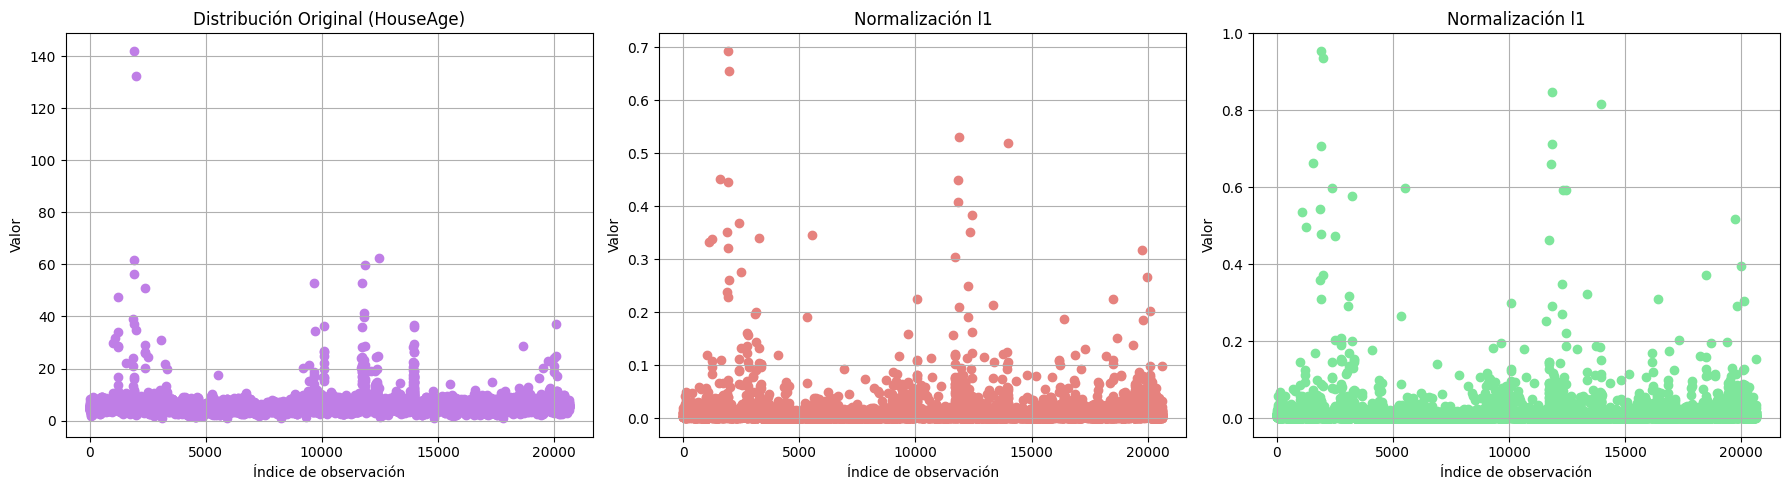

In [ ]:
variable_to_plot_index = 1 #Se escogió 'HouseAge'

valores_originales = datos_para_normalizar[:, variable_to_plot_index]
l1 = datos_normalizados_l1[:, variable_to_plot_index]
l2 = datos_normalizados_l2[:, variable_to_plot_index]

indices = np.arange(len(valores_originales))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

#Gráfica 1: Distribución original
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title('Distribución Original (HouseAge)')
axs[0].set_xlabel('Índice de observación')
axs[0].set_ylabel('Valor')
axs[0].grid(True)

#Gráfica 2: Normalización l1
axs[1].scatter(indices,l1, color='#E6827E')
axs[1].set_title('Normalización l1')
axs[1].set_xlabel('Índice de observación')
axs[1].set_ylabel('Valor')
axs[1].grid(True)

#Gráfica 3: Normalización l2
axs[2].scatter(indices,l2, color='#7EE69B')
axs[2].set_title('Normalización l1')
axs[2].set_xlabel('Índice de observación')
axs[2].set_ylabel('Valor')
axs[2].grid(True)

plt.tight_layout()
plt.show()

#### 6. Análisis

La normalización L1 y L2 hacen que los datos queden en una misma escala, pero lo hacen de forma diferente. L1 reparte los valores para que todos sumen lo mismo, mientras que L2 mantiene mejor las diferencias entre los datos. En las gráficas se ve que ambas reducen los valores, pero L2 conserva mejor qué tan grandes o pequeños son entre sí. Esto hace que los datos se vean más coherentes. Por eso, L2 sería más recomendable.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

#### Librerías

In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

#### 1. Carga de datos

In [ ]:
diabetes = load_diabetes()

#### 2. Conversión a DataFrame

In [ ]:
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


#### 3. Selección de variables numéricas

In [ ]:
selectec_features = ['bp', 's1', 's2']
datos_para_transformar = df[selectec_features].values

#### 4. Aplicación de transformaciones a s1

In [ ]:
variable_to_plot_index = 1  # s1

#Variable original
valores_originales = datos_para_transformar[:, variable_to_plot_index]

#Shift para log y box-cox
valores_shift = valores_originales - np.min(valores_originales) + 1

#1. Transformación logarítmica
log_transform = np.log(valores_shift)

#2. Log reflejado
log_reflejado = np.log(np.max(valores_shift) - valores_shift + 1)

#3. Transformación cuadrática
cuadratica = valores_shift ** 2

#4. Box-Cox
boxcox_transform, lambda_ = boxcox(valores_shift)

#### 5. Gráficas comparativas

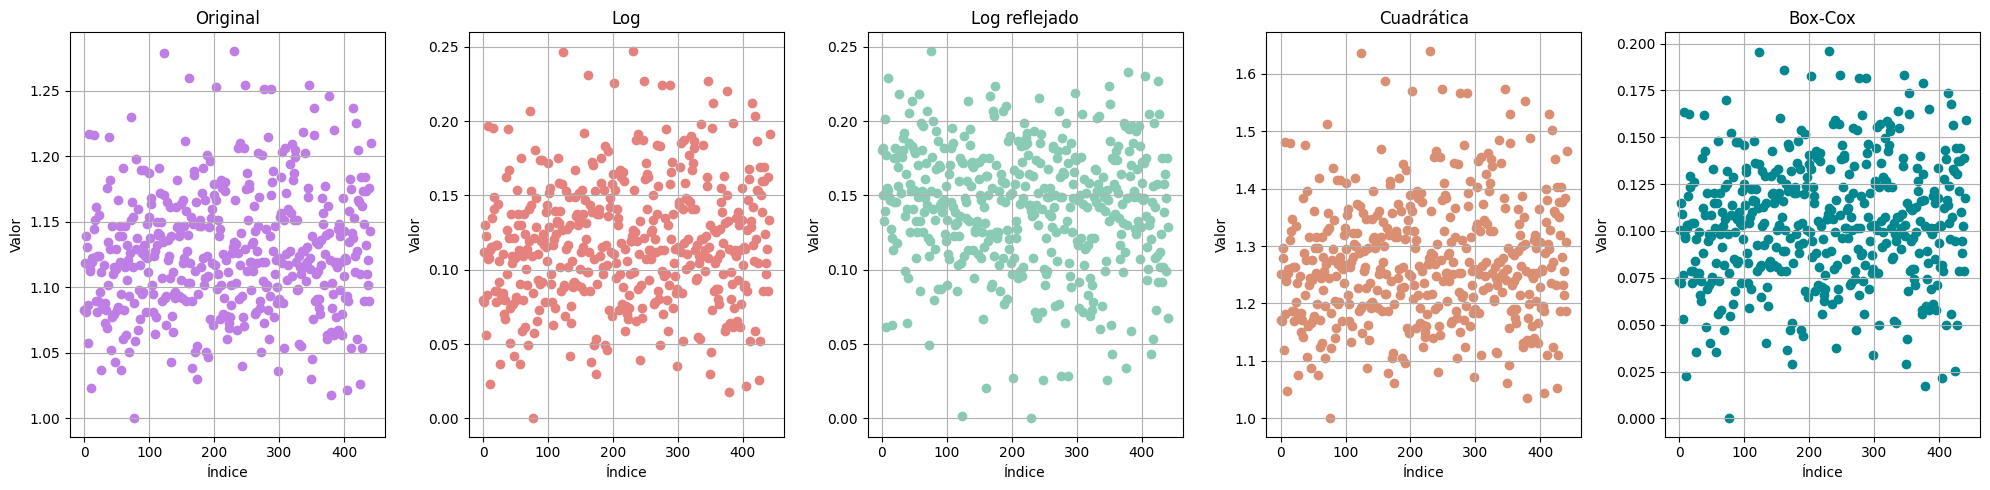

In [ ]:
variable_to_plot_index = 1 #Se escogió 's1'

transformacion_logaritmica = log_transform
logaritmica_reflejada = log_reflejado
cuadratica = cuadratica
box_cox = boxcox_transform

indices = np.arange(len(valores_originales))

fig, axs = plt.subplots(1, 5, figsize=(20, 5))

# Gráfico 0: Original
axs[0].scatter(indices, valores_originales, color='#BF7EE6')
axs[0].set_title('Original')

# Gráfico 1: Transformación logarítmica
axs[1].scatter(indices, transformacion_logaritmica, color='#E6827E')
axs[1].set_title('Log')

# Gráfico 2: Transformación logarítmica reflejada
axs[2].scatter(indices, logaritmica_reflejada, color='#8acbb5')
axs[2].set_title('Log reflejado')

# Gráfico 3: Transformación cuadrática
axs[3].scatter(indices, cuadratica, color='#da8f72')
axs[3].set_title('Cuadrática')

# # Gráfico 4: Box-Cox
axs[4].scatter(indices, box_cox, color='#018790')
axs[4].set_title('Box-Cox')

for ax in axs:
    ax.set_xlabel('Índice')
    ax.set_ylabel('Valor')
    ax.grid(True)

plt.tight_layout()
plt.show()

#### 6. Análisis

Las transformaciones cambian la forma en que se distribuyen los datos. La `logarítmica` reduce un poco los valores altos y hace la distribución más compacta, mientras que la `log reflejada` sirve más cuando los datos están al revés. La `cuadrática` hace lo contrario, amplifica las diferencias y agranda los valores grandes. Por otro lado, `Box-Cox` logra un equilibrio, ajustando la distribución de forma más uniforme.`Box-Cox` sería más recomendable porque adapta mejor los datos sin exagerar los cambios.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `seaborn` usando `load_dataset("heart")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

#### Librerías

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

#### 1. Carga de datos y conversión a DataFrame

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columnas = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
            'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, header=None, names=columnas, na_values='?')
df = df.dropna()
df = df.astype(float)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


#### 3. Selección de variable

In [ ]:
selected_features = ['chol','thalach']
datos_para_transformar = df[selected_features].values

#### 4. Aplicación de transformaciones

In [ ]:
variable_to_plot_index = 0  #Se escogió 'chol'

#Variable original
valores_originales = datos_para_transformar[:, variable_to_plot_index]

# Raíz cuadrada
raiz_cuadrada = np.sqrt(valores_originales)

# Recíproca
reciproca = 1 / valores_originales

#Yeo-Johnson
pt = PowerTransformer(method="yeo-johnson")
yeo_johnson = pt.fit_transform(valores_originales.reshape(-1, 1)).flatten()

#### 5. Gráficas comparativas

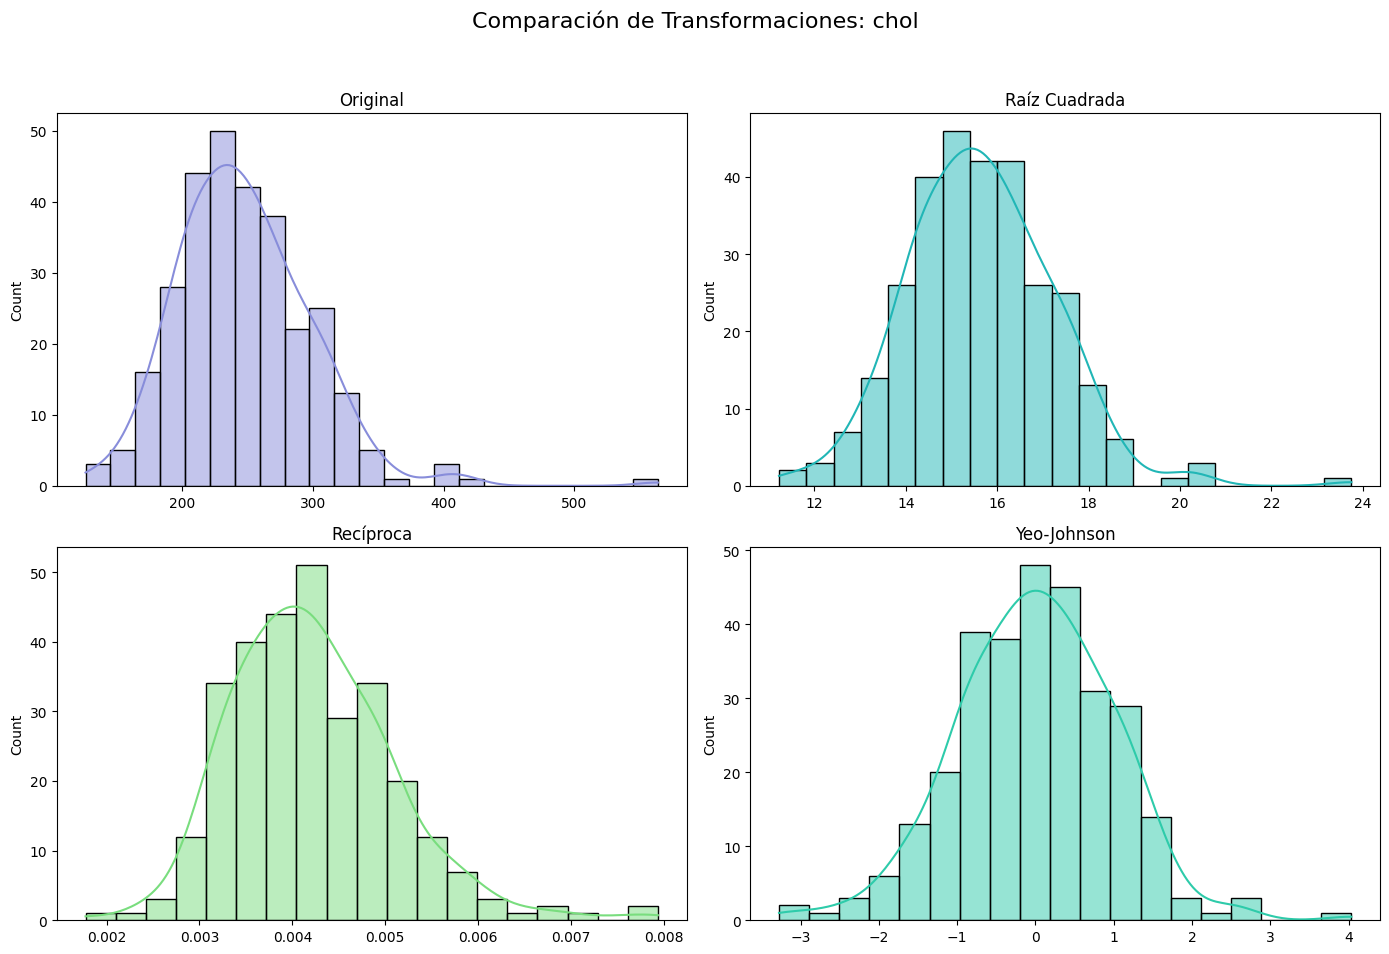

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Comparación de transformaciones: {selected_features[variable_to_plot_index]}', fontsize=16)

#Configuración de los subplots
titulos = ['Original', 'Raíz Cuadrada', 'Recíproca', 'Yeo-Johnson']
datos_list = [valores_originales, raiz_cuadrada, reciproca, yeo_johnson]
colores = ['#888dda', '#21b6b6', '#79dd7e', '#2ecbaa']

for i, ax in enumerate(axes.flat):
    sns.histplot(datos_list[i], kde=True, ax=ax, color=colores[i])
    ax.set_title(titulos[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### 6. Análisis

Mientras que la ` raíz cuadrada`  suaviza levemente la asimetría y la ` recíproca`  comprime los valores altos de forma más drástica, ninguna logra la simetría perfecta de ` Yeo-Johnson` . Esta última técnica se ajusta automáticamente para maximizar la normalidad de los datos, a diferencia de los métodos fijos que son menos flexibles. Al observar los histogramas, se aprecia que ` Yeo-Johnson` centra mejor la campana y estabiliza mejor la varianza.